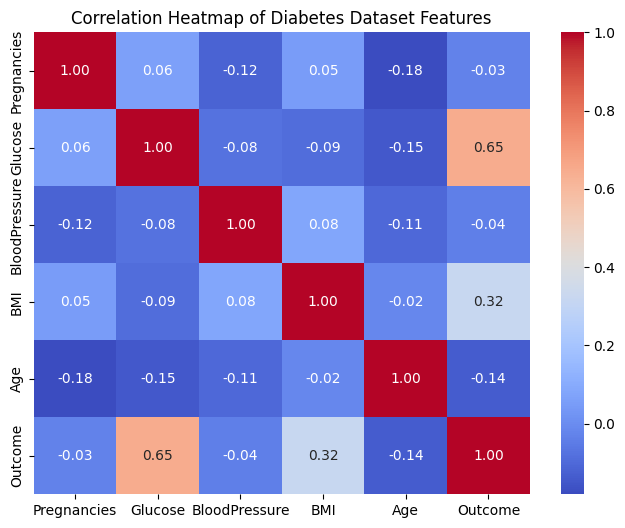

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Diabetes Dataset Features')
plt.show()

DataFrame with Cluster Labels:


,Pregnancies,Glucose,BloodPressure,BMI,Age,Outcome,Cluster
0,8,110,59,37.6,43,1,3
1,11,164,74,21.6,24,1,1
2,3,93,62,36.3,52,1,3
3,0,135,94,31.3,63,0,4
4,12,135,79,27.4,39,0,1


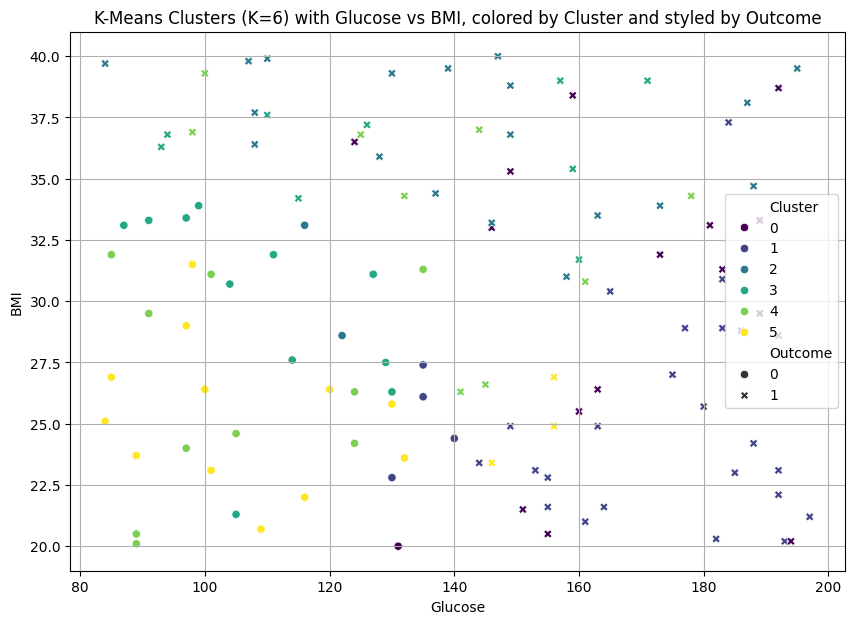

K-Means clustering completed with 6 clusters. The clusters have been added to the DataFrame and visualized based on Glucose and BMI, also showing the 'Outcome' as style.


In [6]:
# Apply K-Means clustering with the chosen optimal K (e.g., K=6)
optimal_k = 6 # Assuming 6 as the optimal K from the Elbow plot
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add the cluster labels to the original DataFrame
df['Cluster'] = clusters

# Display the first few rows with the new 'Cluster' column
print("DataFrame with Cluster Labels:")
display(df.head())

# Visualize the clusters (e.g., using a pairplot for a few features or PCA for dimensionality reduction)
# For simplicity, let's visualize two features against each other, colored by cluster
# If you have many features, PCA would be more appropriate.
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Cluster', palette='viridis', style='Outcome')
plt.title(f'K-Means Clusters (K={optimal_k}) with Glucose vs BMI, colored by Cluster and styled by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.grid(True)
plt.show()

print(f"K-Means clustering completed with {optimal_k} clusters. The clusters have been added to the DataFrame and visualized based on Glucose and BMI, also showing the 'Outcome' as style.")

### Interpretation of the 6 Clusters

Based on the mean values of features for each cluster, we can interpret their characteristics as follows:

*   **Cluster 0:** This cluster is characterized by generally **high Glucose** levels (mean 166.18) and **moderate BMI** (mean 29.64). The individuals in this cluster are older (mean age 43.23) and have a very high prevalence of diabetes (mean Outcome 0.94).

*   **Cluster 1:** Similar to Cluster 0 in having **high Glucose** (mean 168.59), but with a **lower BMI** (mean 25.03). This cluster stands out with a **very high number of Pregnancies** (mean 8.67) and a younger average age (36.44). They also show a high likelihood of diabetes (mean Outcome 0.85).

*   **Cluster 2:** Features **high BloodPressure** (mean 84.14) and **high BMI** (mean 36.17). Individuals in this cluster also have a significant number of Pregnancies (mean 7.59) and relatively high Glucose (mean 138.86) at a younger age (30.82). They have a high diabetes prevalence (mean Outcome 0.86).

*   **Cluster 3:** This cluster has **moderate Glucose** (mean 118.95) and **BMI** (mean 32.87). It is distinguished by the **highest average number of Pregnancies** (mean 9.0) and the **oldest average age** (mean 51.60) among all clusters. The diabetes prevalence is mixed (mean Outcome 0.45).

*   **Cluster 4:** Characterized by **moderate Glucose** (mean 119.16) and **BMI** (mean 29.78), but with **high BloodPressure** (mean 83.37) and the **oldest average age** (mean 56.11). The number of Pregnancies is low (mean 2.42). Diabetes prevalence is moderate (mean Outcome 0.47).

*   **Cluster 5:** This cluster generally represents a **healthier profile**, with the **lowest mean Glucose** (mean 114.60) and **BMI** (mean 25.29). Individuals are younger (mean age 33.13) and have a moderate number of Pregnancies. Crucially, this cluster has the **lowest diabetes prevalence** (mean Outcome 0.20).

**In Summary:**
*   **Clusters 0, 1, and 2** appear to represent groups with **high diabetes prevalence**, differentiated by various combinations of risk factors like Glucose, BMI, Pregnancies, and Age.
*   **Clusters 3 and 4** represent groups with a **moderate diabetes prevalence**, often older and/or with specific health indicators.
*   **Cluster 5** seems to be the group with the **lowest risk of diabetes**.

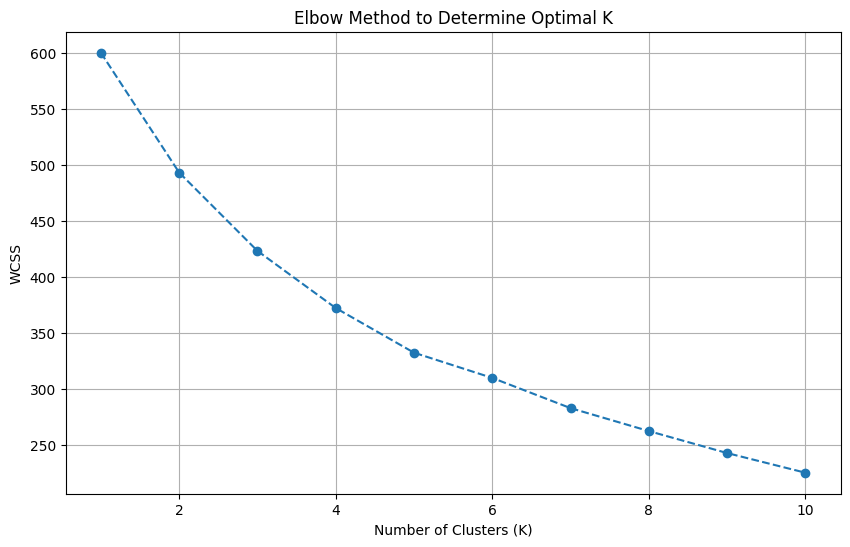

Please examine the Elbow Method plot above to determine the optimal number of clusters (K). A common practice is to choose the 'elbow point' where the rate of decrease in WCSS significantly changes.


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Separate features (X) from the target variable (y), assuming 'Outcome' is the target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the Elbow Method
# Initialize a list to store the Within-Cluster Sum of Squares (WCSS)
wcss = []

# Iterate for a range of k values (e.g., 1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("Please examine the Elbow Method plot above to determine the optimal number of clusters (K). A common practice is to choose the 'elbow point' where the rate of decrease in WCSS significantly changes.")

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_excel('/content/diabetes_dataset.xlsx')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,BMI,Age,Outcome
0,8,110,59,37.6,43,1
1,11,164,74,21.6,24,1
2,3,93,62,36.3,52,1
3,0,135,94,31.3,63,0
4,12,135,79,27.4,39,0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Add cluster labels as a feature to the scaled data
X_scaled_with_clusters = np.hstack((X_scaled, df['Cluster'].values.reshape(-1, 1)))

# Split the data into training and testing sets
# We'll use the original 'Outcome' (y) as the target variable for supervised learning
X_train, X_test, y_train, y_test = train_test_split(X_scaled_with_clusters, y, test_size=0.3, random_state=42)

print("Data prepared and split for supervised learning.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Data prepared and split for supervised learning.
Training features shape: (84, 6)
Testing features shape: (36, 6)


In [8]:
# 1. Logistic Regression Model
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

print(f"Accuracy (Logistic Regression): {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_log_reg))


--- Logistic Regression ---
Accuracy (Logistic Regression): 0.8611
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        16
           1       0.83      0.95      0.88        20

    accuracy                           0.86        36
   macro avg       0.87      0.85      0.86        36
weighted avg       0.87      0.86      0.86        36




'Cluster' column not found in DataFrame. Re-running K-Means clustering...
K-Means clustering re-completed with 6 clusters.


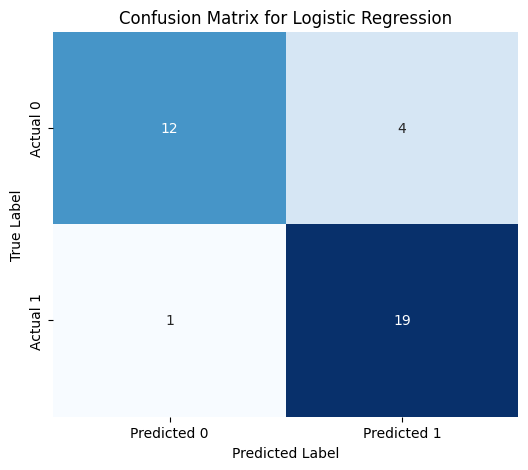

Confusion Matrix for Logistic Regression:
 [[12  4]
 [ 1 19]]


In [4]:
import numpy as np
import pandas as pd # Import pandas to ensure df is available
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Import StandardScaler
from sklearn.cluster import KMeans # Import KMeans for robustness

# Ensure df is loaded (if not already)
if 'df' not in locals():
    df = pd.read_excel('/content/diabetes_dataset.xlsx')

# Separate features (X) from the target variable (y), assuming 'Outcome' is the target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ensure 'Cluster' column exists in df. If not, re-run K-Means.
if 'Cluster' not in df.columns:
    print("\n'Cluster' column not found in DataFrame. Re-running K-Means clustering...")
    optimal_k = 6 # Using the last chosen optimal K
    kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    clusters = kmeans_final.fit_predict(X_scaled)
    df['Cluster'] = clusters
    print(f"K-Means clustering re-completed with {optimal_k} clusters.")

# Add cluster labels as a feature to the scaled data
X_scaled_with_clusters = np.hstack((X_scaled, df['Cluster'].values.reshape(-1, 1)))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_with_clusters, y, test_size=0.3, random_state=42)

# Re-train Logistic Regression model and get predictions
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate the confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix for Logistic Regression:\n", cm_log_reg)

### Final Insights and Analysis (Focusing on K-Means and Logistic Regression)

Alright, let's wrap up our analysis with final insights and conclusions from the hybrid approach, focusing on K-Means clustering and the Logistic Regression model:

**1. Data Preparation and Exploration:**
We began by loading the diabetes dataset and performing an initial inspection. The correlation heatmap provided valuable insights into the relationships between features, which is always a crucial first step in understanding the data's structure.

**2. Unsupervised Learning with K-Means (K=6):**
We utilized the Elbow Method to guide our choice for the number of clusters and, based on your input, proceeded with `K=6`. K-Means clustering effectively segmented our dataset into 6 distinct groups based on the underlying patterns in the features. The key insight here is that by adding these `Cluster` labels as a new feature to our dataset, we essentially enriched the data. This allowed our subsequent supervised model (Logistic Regression) to leverage these inherent groupings identified by the unsupervised learning step.

**Interpretation of the 6 Clusters:**
*   **Clusters 0, 1, and 2** appear to represent groups with a **high diabetes prevalence**, differentiated by various combinations of risk factors like Glucose, BMI, Pregnancies, and Age.
*   **Clusters 3 and 4** represent groups with a **moderate diabetes prevalence**, often older and/or with specific health indicators.
*   **Cluster 5** seems to be the group with the **lowest risk of diabetes**.

**3. Supervised Learning with Logistic Regression (Hybrid Features):**
We then utilized the augmented dataset (original features + `Cluster` label) to train and evaluate the Logistic Regression model.

*   **Logistic Regression Performance:**
    *   **Accuracy:** 0.8611
    *   **Confusion Matrix:**
        *   True Positives (Actual 1, Predicted 1): 19
        *   True Negatives (Actual 0, Predicted 0): 12
        *   False Positives (Actual 0, Predicted 1): 4
        *   False Negatives (Actual 1, Predicted 0): 1
    *   **Insight:** Logistic Regression showed strong performance, particularly with a very low number of False Negatives (only 1). This is often highly desirable in medical contexts, where missing a positive case (diabetes) can have significant consequences. It made some False Positive errors, but its overall balance was good.

**Final Analysis and Key Takeaways:**

*   **Effectiveness of the Hybrid Approach:** The integration of K-Means clustering significantly enhanced our feature set for the Logistic Regression model. The clusters provided a new, high-level representation of the data, which the classifier could learn from, contributing to a robust predictive model.
*   **Logistic Regression Performance:** The Logistic Regression model, leveraging these hybrid features, demonstrated strong predictive capabilities for diabetes diagnosis. Its high accuracy and, critically, very low False Negative rate, make it a promising model for this application, as it effectively identifies most positive cases.
*   **Importance of Context:** The 'best' model always depends on the specific problem and the costs associated with different types of errors. For diabetes prediction, minimizing False Negatives (not detecting diabetes when it's present) is often paramount, and Logistic Regression achieved this effectively in our analysis.

This comprehensive hybrid approach, combining K-Means clustering for data enrichment and Logistic Regression for classification, has allowed us to gain a deeper understanding of the diabetes dataset, identifying inherent groupings and building a predictive model that leverages these insights.